In [1]:
!git clone https://github.com/dramirezbe/DataBase-RF-FM-88MHz-108MHz-Bogota-Funza.git

Cloning into 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 55 (delta 2), reused 16 (delta 2), pack-reused 37 (from 1)
Receiving objects: 100% (55/55), 281.05 MiB | 2.18 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Updating files: 100% (14/14), done.


Loading CSVs...


Processing records: 100%|██████████| 104/104 [01:40<00:00,  1.04it/s]



Plotting Telemetry Data...


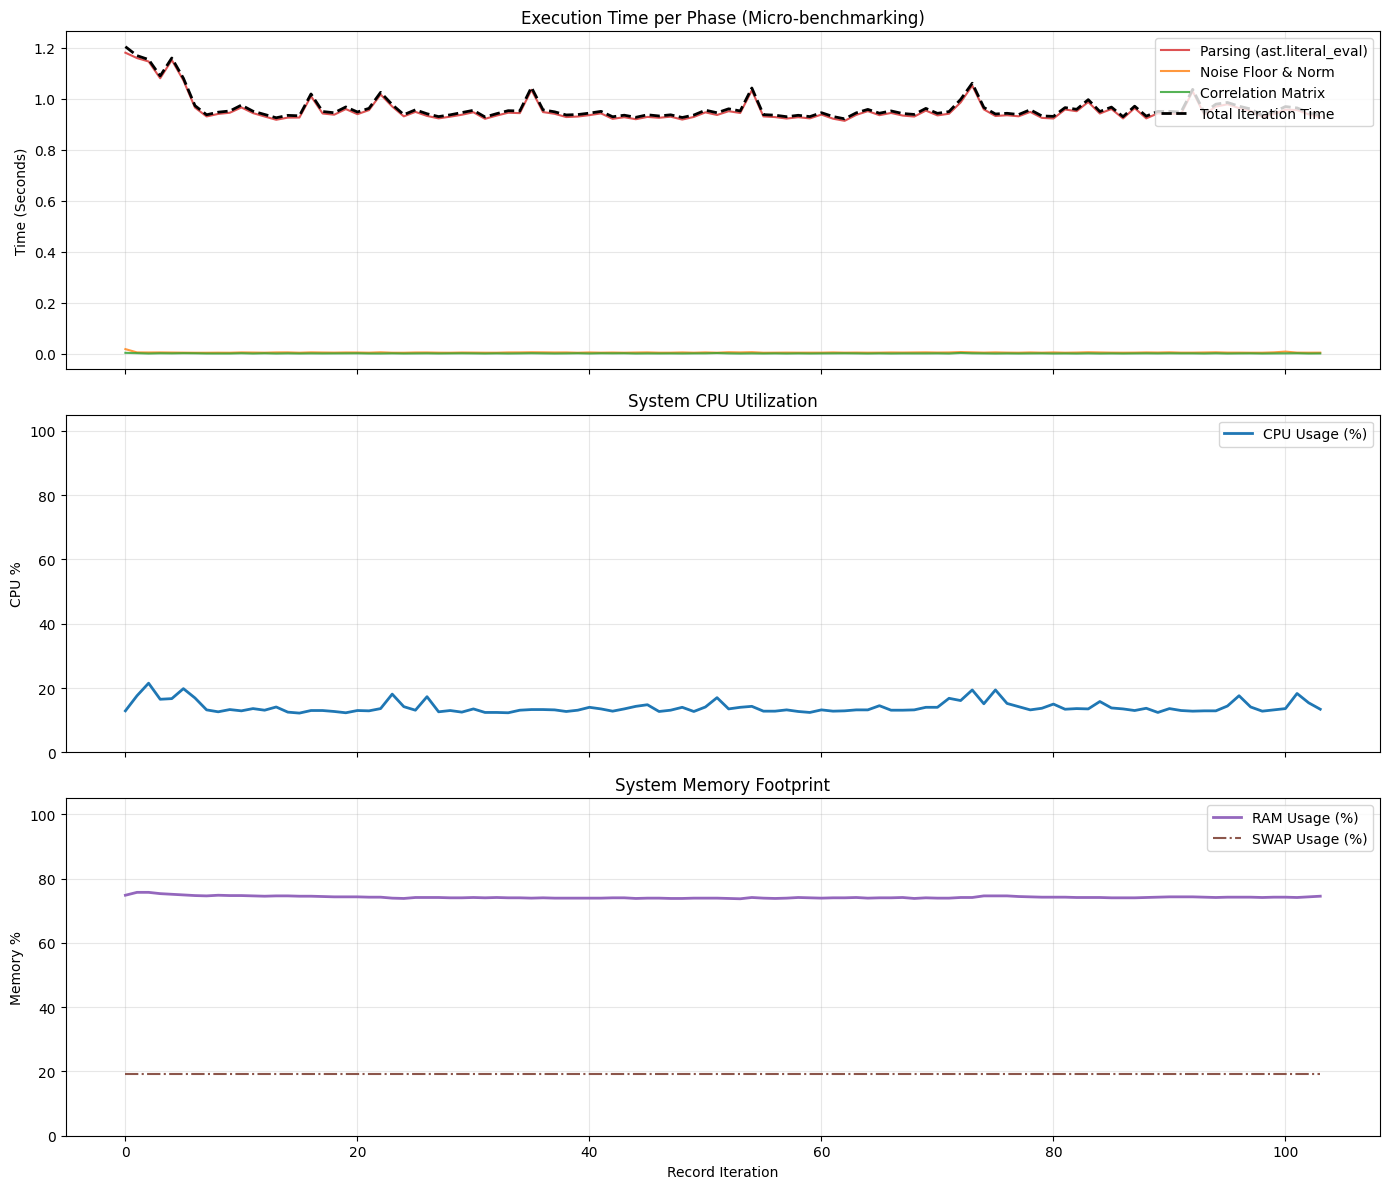


✅ Telemetry complete.


In [2]:
import pandas as pd
import glob
import ast
import numpy as np
import matplotlib.pyplot as plt
import psutil
import time
from tqdm import tqdm

# ── 1. Load Data ──────────────────────────────────────────────────────────
archivos = glob.glob("DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv")
datos_nodos = {}

EXCLUDE = {
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota",
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota",
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota",
}

print("Loading CSVs...")
for archivo in archivos:
    nombre_nodo = archivo.replace('.csv', '')
    if nombre_nodo in EXCLUDE:
        continue
    datos_nodos[nombre_nodo] = pd.read_csv(archivo)

node_names = sorted(datos_nodos.keys())
n_nodes = len(node_names)

# ── 2. Telemetry & Timing Setup ───────────────────────────────────────────
safe_max = 103
var_eps = 1e-10

# Pre-allocate lists for telemetry to avoid memory fragmentation
telemetry = {
    'cpu_percent': [],
    'ram_percent': [],
    'swap_percent': [],
    'time_parsing': [],
    'time_noise': [],
    'time_correlation': [],
    'time_total': []
}

all_ranked_scores = {node: [] for node in node_names}

# ── 3. Main Processing Loop ───────────────────────────────────────────────
for data_record in tqdm(range(safe_max + 1), desc="Processing records"):
    
    t_start_total = time.perf_counter()
    
    # Track System Resources at the start of the loop
    telemetry['cpu_percent'].append(psutil.cpu_percent(interval=None))
    telemetry['ram_percent'].append(psutil.virtual_memory().percent)
    telemetry['swap_percent'].append(psutil.swap_memory().percent)

    pxx_indexed = {}
    noise_floor_estimates = {}
    
    # -- PHASE A: Parsing --
    t0 = time.perf_counter()
    for nombre_nodo, df in datos_nodos.items():
        pxx_raw = df['pxx'].iloc[data_record]
        # FIXED: Removed the duplicate ast.literal_eval call
        pxx_indexed[nombre_nodo] = np.array(ast.literal_eval(pxx_raw))
    telemetry['time_parsing'].append(time.perf_counter() - t0)

    # -- PHASE B: Noise Floor & Normalization --
    t0 = time.perf_counter()
    for nombre_nodo, pxx in pxx_indexed.items():
        N_bins = int(np.ceil(np.log2(len(pxx)) + 1))
        counts, bin_edges = np.histogram(pxx, bins=N_bins)
        k = np.argmax(counts)
        noise_floor_estimates[nombre_nodo] = 0.5 * (bin_edges[k] + bin_edges[k + 1])

    global_noise_mean = np.mean(list(noise_floor_estimates.values()))

    pxx_processed = {}
    is_valid = {}

    for nombre_nodo, pxx_orig in pxx_indexed.items():
        offset = global_noise_mean - noise_floor_estimates[nombre_nodo]
        pxx_recentered = pxx_orig + offset
        orig_std = np.std(pxx_recentered)
        
        is_valid[nombre_nodo] = orig_std > var_eps
        
        if is_valid[nombre_nodo]:
            pxx_processed[nombre_nodo] = (pxx_recentered - np.mean(pxx_recentered)) / orig_std
        else:
            pxx_processed[nombre_nodo] = np.zeros_like(pxx_recentered, dtype=float)
            
    telemetry['time_noise'].append(time.perf_counter() - t0)

    # -- PHASE C: Vectorized Correlation Matrix --
    t0 = time.perf_counter()
    
    # Create a full correlation matrix initialized to zeros
    corr_matrix = np.eye(n_nodes, dtype=float)
    
    # Get only valid nodes to avoid divide-by-zero errors in correlation
    valid_indices = [i for i, node in enumerate(node_names) if is_valid[node]]
    valid_nodes = [node_names[i] for i in valid_indices]
    
    if len(valid_nodes) > 1:
        # Stack into a 2D matrix: shape (num_valid_nodes, num_frequencies)
        matrix = np.array([pxx_processed[node] for node in valid_nodes])
        
        # Vectorized Pearson calculation (Instantaneous compared to nested loops)
        valid_corr_matrix = np.corrcoef(matrix)
        
        # Map the valid correlations back into the full matrix
        for idx_i, orig_i in enumerate(valid_indices):
            for idx_j, orig_j in enumerate(valid_indices):
                corr_matrix[orig_i, orig_j] = valid_corr_matrix[idx_i, idx_j]

    # Cumulative scores + ranking
    cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0
    
    for node, score in zip(node_names, cumulative_scores):
        all_ranked_scores[node].append(score)
        
    telemetry['time_correlation'].append(time.perf_counter() - t0)
    telemetry['time_total'].append(time.perf_counter() - t_start_total)

# ── 4. Plotting Telemetry & Performance ───────────────────────────────────
print("\nPlotting Telemetry Data...")

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
records_axis = range(safe_max + 1)

# Plot 1: Execution Times
axs[0].plot(records_axis, telemetry['time_parsing'], label='Parsing (ast.literal_eval)', color='tab:red', alpha=0.8)
axs[0].plot(records_axis, telemetry['time_noise'], label='Noise Floor & Norm', color='tab:orange', alpha=0.8)
axs[0].plot(records_axis, telemetry['time_correlation'], label='Correlation Matrix', color='tab:green', alpha=0.8)
axs[0].plot(records_axis, telemetry['time_total'], label='Total Iteration Time', color='black', linestyle='--', linewidth=2)
axs[0].set_ylabel('Time (Seconds)')
axs[0].set_title('Execution Time per Phase (Micro-benchmarking)')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

# Plot 2: CPU Usage
axs[1].plot(records_axis, telemetry['cpu_percent'], label='CPU Usage (%)', color='tab:blue', linewidth=2)
axs[1].set_ylabel('CPU %')
axs[1].set_title('System CPU Utilization')
axs[1].set_ylim(0, 105)
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

# Plot 3: Memory Usage
axs[2].plot(records_axis, telemetry['ram_percent'], label='RAM Usage (%)', color='tab:purple', linewidth=2)
axs[2].plot(records_axis, telemetry['swap_percent'], label='SWAP Usage (%)', color='tab:brown', linestyle='-.')
axs[2].set_xlabel('Record Iteration')
axs[2].set_ylabel('Memory %')
axs[2].set_title('System Memory Footprint')
axs[2].set_ylim(0, 105)
axs[2].legend(loc='upper right')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig) # Prevent memory leak in Notebooks

print("\n✅ Telemetry complete.")